In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Task 1:Exploratory Data Analysis (EDA)

In [ ]:
df=pd.read_csv("Data\Fifa.csv")

In [3]:
df.shape

(19667, 9)

- The dataset has 19,667 players and 9 columns.

In [4]:
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


- as we see we have 5 numircal features and 4 Categorical features

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


In [6]:
df.duplicated().sum()

np.int64(0)

- as shown there ara no duplicated

In [7]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

- as shown there ara no null values

In [8]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


- Age: ranges from 15 to 44, with an average of 22.99, indicating that most players are relatively young.
- Overall Rating: ranges from 36 to 91, with a mean of 63.23, showing that the majority of players have moderate skill levels.
- Future Potential: ranges from 46 to 95, with an average of 70.66, suggesting many players can develop.
- Value Per M$: ranges from 0 to 190.5, showing huge differeence between players,because some of them ara.
-Total Stats Score: ranges from 416 to 2324, reflecting major differences in player abilities.


## Distribution of Value Per M$

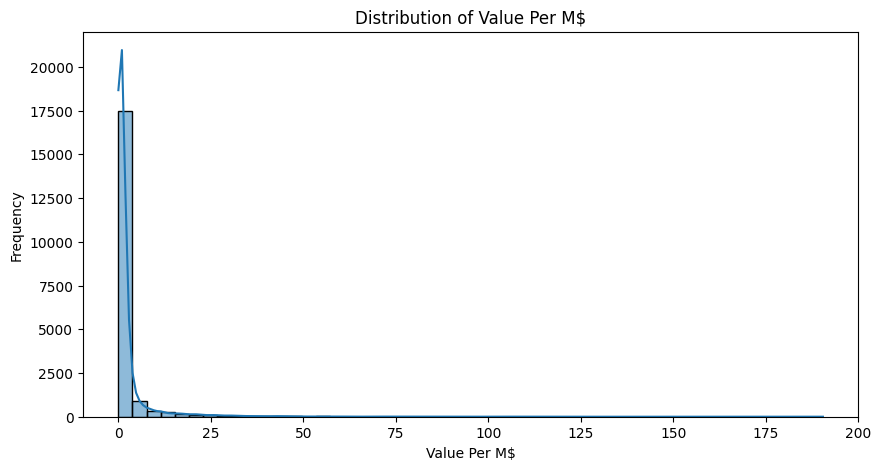

Skewness = 7.983215201865151


In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df["Value Per M$"], bins=50, kde=True)
plt.title("Distribution of Value Per M$")
plt.xlabel("Value Per M$")
plt.ylabel("Frequency")
plt.show()
skew_value = df["Value Per M$"].skew()
print("Skewness =", skew_value)

- as we see the distribution of Value Per M$ is highly positively skewed (right-skewed) and is not approximately normal.



## Which numerical features seem most related to Value Per M$?

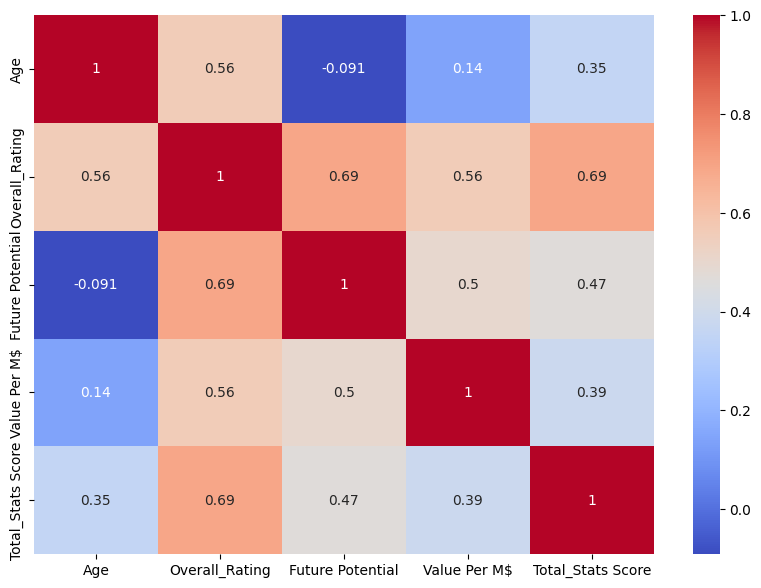

In [10]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

- as shown the most related to Value Per M$ is Overall_Rating 



## What is the average Overall_Rating per Position? 

In [11]:
df.groupby('Position')['Overall_Rating'].mean()

Position
CAM    63.679709
CB     63.544448
CDM    64.234168
CF     66.042857
CM     62.511767
GK     60.987288
LB     63.276794
LM     64.172009
LW     64.345979
LWB    64.043333
RB     62.863636
RF     75.000000
RM     63.907731
RW     63.718529
RWB    64.063973
ST     63.087505
SW     75.000000
Name: Overall_Rating, dtype: float64

<Axes: xlabel='Position', ylabel='Overall_Rating'>

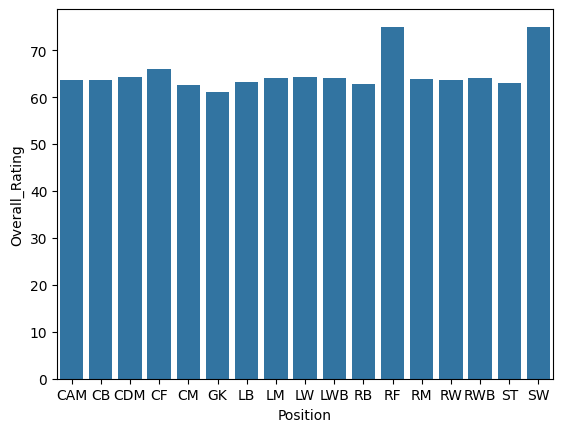

In [12]:
sns.barplot(df.groupby('Position')['Overall_Rating'].mean())

---

# Task 2: Data Preprocessing

In [13]:
df.drop(columns=['Name','Country'],inplace=True)

- drop unuseful feautures

In [14]:
from sklearn.model_selection import train_test_split
X = df.drop('Value Per M$', axis=1)    
y = df['Value Per M$']                
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2 ,random_state=42 )
print(f'Training set size : {X_train.shape}')
print(f'Test set size: {X_test.shape}')

Training set size : (15733, 6)
Test set size: (3934, 6)


- Split the dataset into Train and Test sets



## Outlier Detection and Removal

In [15]:
train_df = X_train.copy()
train_df['Value Per M$'] = y_train.values
outlier_cols = ['Value Per M$', 'Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
print(train_df.shape)

(15733, 7)


- Outlier Preparation:
We copy X_train and add the target column Value Per M$ to create train_df.
We also define the columns that will be checked for outliers.
Finally, we print the dataset shape before removing outliers.

In [16]:
for col in outlier_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train_df = train_df[(train_df[col] >= lower) & (train_df[col] <= upper)]

In [17]:
train_df = train_df.reset_index(drop=True)
print(train_df.shape)
print(X_train.shape[0] - train_df.shape[0])

(12375, 7)
3358


In [18]:
X_train_clean = train_df.drop(columns=['Value Per M$'])
y_train_clean = train_df['Value Per M$']

- we separated X_train_clean and y_train_clean

In [19]:
X_train

,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,LW,25,67,70,Gil Vicente,1689
10392,ST,19,55,68,Midtjylland,1351
8124,RW,32,75,75,Rio Ave,2049
13075,ST,17,61,71,Belenenses,1448
19445,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...
11284,CM,19,59,70,Delfin,1680
11964,CB,27,67,68,Ingolstadt,1557
5390,ST,24,63,67,Shonan Bellmare,1568
860,CM,25,81,82,Leicester City,2042


In [20]:
y_train

10156     1.300
10392     0.300
8124      3.900
13075     0.675
19445     1.300
          ...  
11284     0.475
11964     1.000
5390      0.700
860      27.500
15795     1.200
Name: Value Per M$, Length: 15733, dtype: float64

In [21]:
X_train_clean

,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
0,LW,25,67,70,Gil Vicente,1689
1,ST,19,55,68,Midtjylland,1351
2,ST,17,61,71,Belenenses,1448
3,RB,28,69,69,Wanderers,1748
4,CM,24,70,73,Borussia Dortmund,1960
...,...,...,...,...,...,...
12370,CB,19,58,71,Sint-Truiden,1383
12371,CM,19,59,70,Delfin,1680
12372,CB,27,67,68,Ingolstadt,1557
12373,ST,24,63,67,Shonan Bellmare,1568


In [22]:
y_train_clean

0        1.300
1        0.300
2        0.675
3        1.300
4        2.200
         ...  
12370    0.450
12371    0.475
12372    1.000
12373    0.700
12374    1.200
Name: Value Per M$, Length: 12375, dtype: float64

## Encoding Categorical Features (One-Hot Encoding)

#### Why We Use One-Hot Encoding

We use One-Hot Encoding instead of Label Encoding because Label Encoding assigns numbers to categories (like 0, 1, 2) which can wrongly make the model think there is an order or ranking between them.
One-Hot Encoding solves this by creating separate columns for each category with values 0 or 1 so all categories are treated equally without any order.

In [23]:
cat_cols = X_train_clean.select_dtypes(include='object').columns.tolist()
cat_cols

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_45820\2995957462.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_clean.select_dtypes(include='object').columns.tolist()


['Position', 'Team']

In [24]:
X_train_encoded = pd.get_dummies(X_train_clean, columns=cat_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test,columns=cat_cols, drop_first=True)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
print(f'\nShape after encoding  Train: {X_train_encoded.shape}, Test: {X_test_encoded.shape}')
X_train_encoded.head()


Shape after encoding  Train: (12375, 994), Test: (3934, 994)


,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
0,25,67,70,1689,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,19,55,68,1351,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,17,61,71,1448,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,28,69,69,1748,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,24,70,73,1960,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False



## Scale numerical features:

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = X_train_encoded.select_dtypes(include='number').columns
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns)

- Why StandardScaler over MinMaxScaler  
We use Standard Scaling to make  features have a mean of 0 and a standard deviation of 1.
This is important because it ensures that all features are on the same scale, so no feature dominates others due to large values.
We prefer Standard Scaling because it works well with many machine learning models like Logistic Regression, SVM, KNN, and Neural Networks.

In [26]:
X_train_scaled.head()

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
0,0.608355,0.894827,0.066601,0.784206,-0.440889,-0.281563,-0.116604,-0.391684,-0.221148,-0.254361,...,-0.029827,-0.034837,-0.032429,-0.028438,-0.020105,-0.02379,-0.031155,-0.035981,-0.015572,-0.035981
1,-0.818288,-1.132108,-0.314000,-0.906743,-0.440889,-0.281563,-0.116604,-0.391684,-0.221148,-0.254361,...,-0.029827,-0.034837,-0.032429,-0.028438,-0.020105,-0.02379,-0.031155,-0.035981,-0.015572,-0.035981
2,-1.293836,-0.118640,0.256902,-0.421471,-0.440889,-0.281563,-0.116604,-0.391684,-0.221148,-0.254361,...,-0.029827,-0.034837,-0.032429,-0.028438,-0.020105,-0.02379,-0.031155,-0.035981,-0.015572,-0.035981
3,1.321677,1.232649,-0.123699,1.079371,-0.440889,-0.281563,-0.116604,-0.391684,-0.221148,-0.254361,...,-0.029827,-0.034837,-0.032429,-0.028438,-0.020105,-0.02379,-0.031155,-0.035981,-0.015572,-0.035981
4,0.370582,1.401560,0.637504,2.139966,-0.440889,-0.281563,-0.116604,2.553082,-0.221148,-0.254361,...,-0.029827,-0.034837,-0.032429,-0.028438,-0.020105,-0.02379,-0.031155,-0.035981,-0.015572,-0.035981


In [27]:
print(X_train_scaled[:6])

        Age  Overall_Rating  Future Potential  Total_Stats Score  Position_CB  \
0  0.608355        0.894827          0.066601           0.784206    -0.440889   
1 -0.818288       -1.132108         -0.314000          -0.906743    -0.440889   
2 -1.293836       -0.118640          0.256902          -0.421471    -0.440889   
3  1.321677        1.232649         -0.123699           1.079371    -0.440889   
4  0.370582        1.401560          0.637504           2.139966    -0.440889   
5  0.132808       -0.118640         -0.884902           0.128838    -0.440889   

   Position_CDM  Position_CF  Position_CM  Position_GK  Position_LB  ...  \
0     -0.281563    -0.116604    -0.391684    -0.221148    -0.254361  ...   
1     -0.281563    -0.116604    -0.391684    -0.221148    -0.254361  ...   
2     -0.281563    -0.116604    -0.391684    -0.221148    -0.254361  ...   
3     -0.281563    -0.116604    -0.391684    -0.221148    -0.254361  ...   
4     -0.281563    -0.116604     2.553082    -0.2211

# Task 3 : Classification Target (Logistic Regression + Naïve Bayes)

In [28]:
df['Performance_Tier'] = pd.qcut(df['Overall_Rating'], q=4, labels=['Tier 4', 'Tier 3', 'Tier 2', 'Tier 1'])

In [29]:
def discritize(y):
    v = X_train_scaled['Overall_Rating']
    l = []
    for i in range(len(y)):
        if y[i] < v.quantile(0.25):
            l.append('Tier 4')
        elif y[i] < v.quantile(0.5):
            l.append('Tier 3')
        elif y[i] < v.quantile(0.75):
            l.append('Tier 2')
        else:
            l.append('Tier 1')
    return l

In [30]:
thresholds = df['Overall_Rating'].describe(percentiles=[.25, .5, .75])
print("Defined Thresholds for Performance Tiers:")
print(thresholds)

Defined Thresholds for Performance Tiers:
count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64


###1. Calculate the number of players in each category

In [31]:
counts = df['Performance_Tier'].value_counts().sort_index()
print("\nPlayer Counts per Category:")
print(counts)


Player Counts per Category:
Performance_Tier
Tier 4    5568
Tier 3    5102
Tier 2    4297
Tier 1    4700
Name: count, dtype: int64


#### 2. Plotting the Bar Chart to visualize class distribution

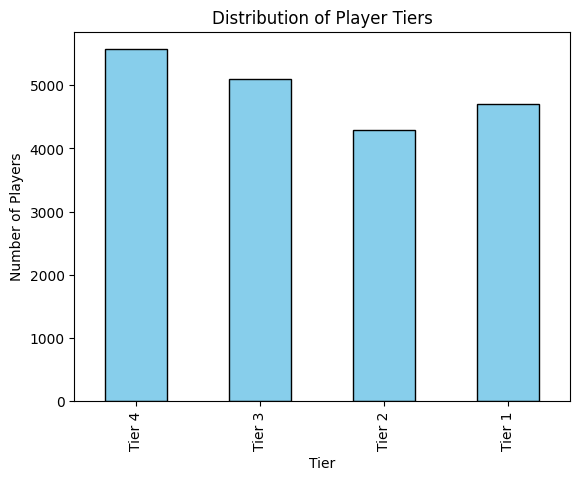

In [32]:
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Player Tiers')
plt.xlabel('Tier')
plt.ylabel('Number of Players')
plt.show()

## Conclusion:
 The dataset is balanced. Since each tier contains approximately 25% of the total players, the classes are evenly distributed. This ensures that the classification models (Logistic Regression and Naïve Bayes) will not be biased toward any specific category.

## Justification:
 We used quantile-based discretization (quartiles) to define the thresholds. This approach was chosen to ensure that the performance tiers are defined relative to the current player population, maintaining an equal number of samples in each class for optimal model training.

---------------------------------------------------
# Task 4: Polynomial Regression

In [33]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,root_mean_squared_error

In [34]:
model = LinearRegression()

In [35]:
def polynomial_feature(dataframe,columns=num_cols,degrees:list=[2,3,4])->pd.DataFrame:
    data = dataframe.copy()

    for deg in degrees:
        for col in columns:
            data[col+'^'+str(deg)] = data[col]**deg

    return data

In [36]:
degrees = 4

In [37]:
X_train_scaled_num = pd.DataFrame(X_train_scaled,columns=X_train_encoded.columns)[num_cols]
X_test_scaled_num = pd.DataFrame(X_test_scaled,columns=X_test_encoded.columns)[num_cols]


In [38]:
scores = {}
for i in range(1,degrees):
    model.fit(polynomial_feature(X_train_scaled_num,num_cols,degrees=[i for i in range(2,i+1)]),y_train_clean)
    predictions = model.predict(polynomial_feature(X_test_scaled_num,num_cols,degrees=[i for i in range(2,i+1)]))

    train_R2 = model.score(polynomial_feature(X_train_scaled_num,num_cols,degrees=[i for i in range(2,i+1)]),y_train_clean)
    test_R2 = r2_score(y_test,predictions)

    scores['Polynomial of Degree '+str(i)] = {'train R2':train_R2,'Test R2':test_R2}


In [39]:
scores

{'Polynomial of Degree 1': {'train R2': 0.7175852178830333,
  'Test R2': 0.07955329286880819},
 'Polynomial of Degree 2': {'train R2': 0.830086193178365,
  'Test R2': 0.20539666872221274},
 'Polynomial of Degree 3': {'train R2': 0.8362094898911515,
  'Test R2': 0.15961588346181688}}

second degree polynomial is the best at genaralizing even though the third degree polynomial is better in the train set

In [40]:
X_train_squared = polynomial_feature(X_train_scaled_num,num_cols,degrees=[2])
X_test_squared = polynomial_feature(X_test_scaled_num,num_cols,degrees=[2])


In [41]:
losses = {}
alpha = np.logspace(-4,1,200)
models = (Ridge,Lasso)
for model in models:
    loss = []
    for a in alpha:
        m = model(alpha=a)
        m.fit(X_train_squared,y_train_clean)
        predictions =  m.predict(X_test_squared)
        loss.append(root_mean_squared_error(y_test,predictions))
    losses[model.__name__] = loss

In [42]:
losses = pd.DataFrame(losses)

In [43]:
losses['alpha'] = alpha

In [44]:
losses

,Ridge,Lasso,alpha
0,7.020735,7.021167,0.000100
1,7.020735,7.021193,0.000106
2,7.020735,7.021220,0.000112
3,7.020735,7.021249,0.000119
4,7.020735,7.021279,0.000126
...,...,...,...
195,7.021525,8.064843,7.934097
196,7.021572,8.064843,8.406653
197,7.021621,8.064843,8.907355
198,7.021674,8.064843,9.437878


<Axes: ylabel='Lasso'>

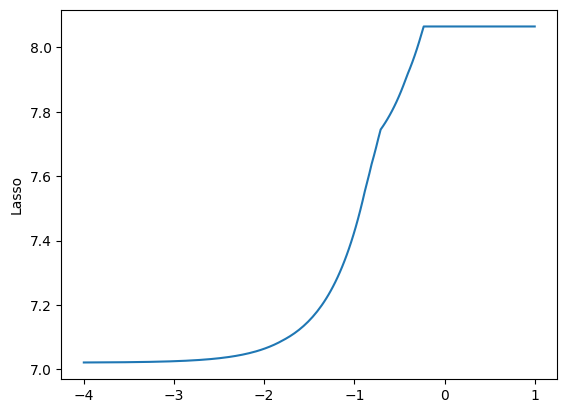

In [45]:
sns.lineplot(x=np.log10(alpha),y=losses['Lasso'])

- the best alpha is 0 since it have the least rmse score

<Axes: ylabel='Ridge'>

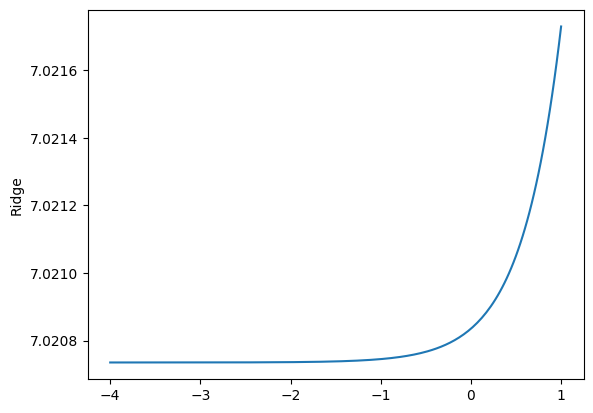

In [46]:
sns.lineplot(x=np.log10(alpha),y=losses['Ridge'])

- the best alpha is 0 since it have the least rmse score

-------------------------------------------------
# Task 5: Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,accuracy_score,precision_score,recall_score, confusion_matrix

In [48]:
X_classification = X_train_scaled.drop(columns=['Overall_Rating'])
y_classification = discritize(X_train_scaled['Overall_Rating'].values)

X_test_classification = X_test_scaled.drop(columns=['Overall_Rating'])
y_test_classification = discritize(X_test_scaled['Overall_Rating'].values)

In [49]:
logistic_regression = LogisticRegression(random_state=42)
logistic_regression.fit(X_classification,y_classification)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [50]:
logisitc_pred = logistic_regression.predict(X_test_scaled.drop(columns=['Overall_Rating']))

<Axes: >

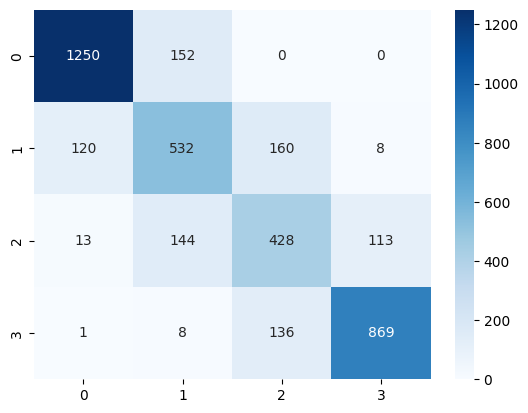

In [51]:
sns.heatmap(confusion_matrix(y_test_classification,logisitc_pred), annot=True, fmt='d', cmap='Blues')

In [117]:
def evaluate_model(y_actual, y_pred):
    print("Accuracy:", accuracy_score(y_actual, y_pred))
    print("Precision:", precision_score(y_actual, y_pred, average='weighted'))
    print("Recall:", recall_score(y_actual, y_pred, average='weighted'))
    print("F1 score:", f1_score(y_actual, y_pred, average='weighted'))

In [120]:
evaluate_model(y_test_classification, logisitc_pred)

Accuracy: 0.78266395526182
Precision: 0.7856563060936752
Recall: 0.78266395526182
F1 score: 0.784066493650292


In [53]:
# logistic_losses = {}
Cs = np.logspace(-3,4,10)

model=LogisticRegression
loss = []
for c in Cs:
    m = model(C=c)
    m.fit(X_classification,y_classification)
    predictions =  m.predict(X_test_classification)
    loss.append(accuracy_score(y_test_classification,predictions))


<Axes: >

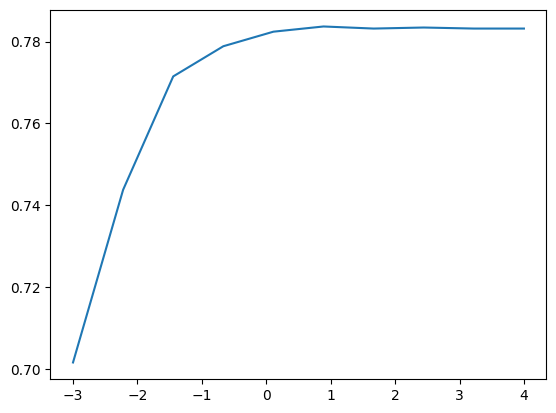

In [54]:
sns.lineplot(x=np.log10(Cs),y=loss)

The best C is ~$10^3$ since it have the highest accurcy

In [55]:
log_reg_l1 = LogisticRegression(C=Cs[np.argmax(loss)], penalty='l1', solver='saga', random_state=42)
log_reg_l1.fit(X_classification,y_classification)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: Th

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(7.742636826811269)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.

In [56]:
log_reg_l2 = LogisticRegression(C=Cs[np.argmax(loss)], penalty='l2', solver='lbfgs', random_state=42)
log_reg_l2.fit(X_classification,y_classification)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(7.742636826811269)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.

In [57]:
pred_l1 = log_reg_l1.predict(X_test_classification)
pred_l2 = log_reg_l2.predict(X_test_classification)

In [58]:
print("L1 Penalty (saga): ",accuracy_score(y_test_classification,pred_l1))
print("L2 Penalty ((lbfgs): ",accuracy_score(y_test_classification,pred_l2))

L1 Penalty (saga):  0.7648703609557702
L2 Penalty ((lbfgs):  0.7836807320793086


- L2 penalty is better than L since it have a higher accurecy

-----------------------------------------------------------------
# Task 6 : Naïve Bayes Classification

## GaussianNB Model

### first with StandardScaler

In [59]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

### selecting required featurtes and training the model on

In [60]:
num_cols_for_gnb = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_gnb = X_train_scaled[num_cols_for_gnb]
X_test_gnb = X_test_scaled[num_cols_for_gnb]

gnb = GaussianNB()
gnb.fit(X_train_gnb, y_classification)
gnb_pred = gnb.predict(X_test_gnb)

### evaluating 

In [62]:
evaluate_model(y_test_classification, gnb_pred)

Accuracy: 0.6769191662430096
Precision: 0.6906637790271631
Recall: 0.6769191662430096
F1 score: 0.6829602416103395


### heatmap showing actual vs predicted

In [63]:
def plot_heatmap(y_test_classification, gnb_pred, title):
    plt.figure(figsize=(8, 6))
    cm_gnb = confusion_matrix(y_test_classification, gnb_pred)
    sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4'],
                yticklabels=['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

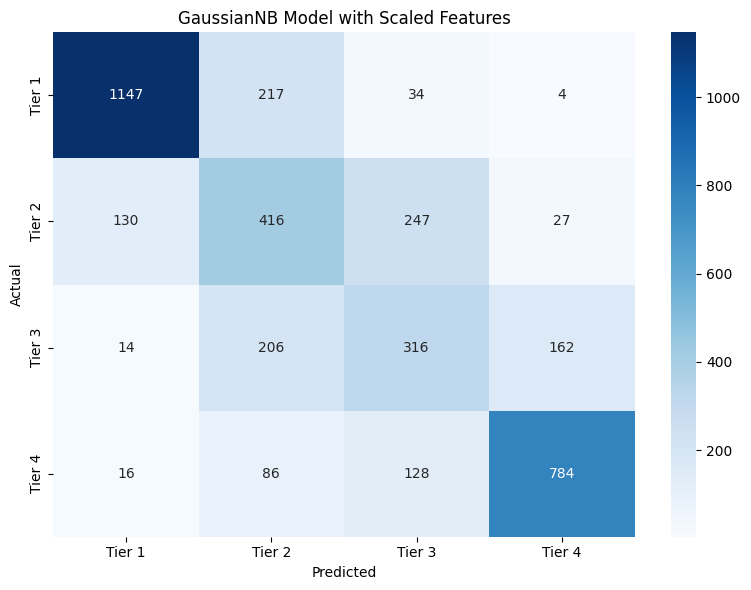

In [64]:
plot_heatmap(y_test_classification, gnb_pred, 'GaussianNB Model with Scaled Features')

### without StandardScaler (encoded features before scoring)

In [65]:
X_train_gnb_2 = X_train_encoded[num_cols_for_gnb]
X_test_gnb_2 = X_test_encoded[num_cols_for_gnb]

gnb_2 = GaussianNB()
gnb.fit(X_train_gnb_2, y_classification)
gnb_pred_2 = gnb.predict(X_test_gnb_2)

In [66]:
evaluate_model(y_test_classification, gnb_pred_2)

Accuracy: 0.6769191662430096
Precision: 0.6906637790271631
Recall: 0.6769191662430096
F1 score: 0.6829602416103395


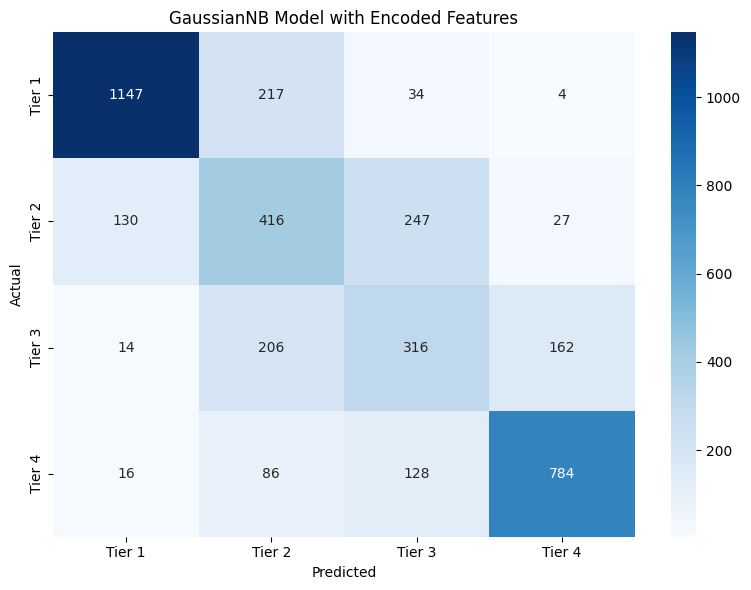

In [67]:
plot_heatmap(y_test_classification, gnb_pred_2, 'GaussianNB Model with Encoded Features')

### Why did GaussianNB get the same score before and after scaling?
#### GaussianNB works differently, it doesnt calculate distance it does better than that by calculating class probabilities using the Gaussian formula for each feature independently, which means changing the scale doesnt affect the model's underlying shape or logic.


## Bernoulli Model

### using only binary features 

In [68]:
from sklearn.naive_bayes import BernoulliNB

In [69]:
binary_cols = [col for col in X_train_encoded.columns if X_train_encoded[col].nunique() == 2]
print(f"Binary cols: {len(binary_cols)}")

Binary cols: 990


In [70]:
X_train_bern = X_train_encoded[binary_cols]
X_test_bern = X_test_encoded[binary_cols]

bnb = BernoulliNB()
bnb.fit(X_train_bern, y_classification)
bnb_pred = bnb.predict(X_test_bern)

In [71]:
evaluate_model(y_test_classification, bnb_pred)

Accuracy: 0.43289273004575496
Precision: 0.43164990268259495
Recall: 0.43289273004575496
F1 score: 0.430675218893857


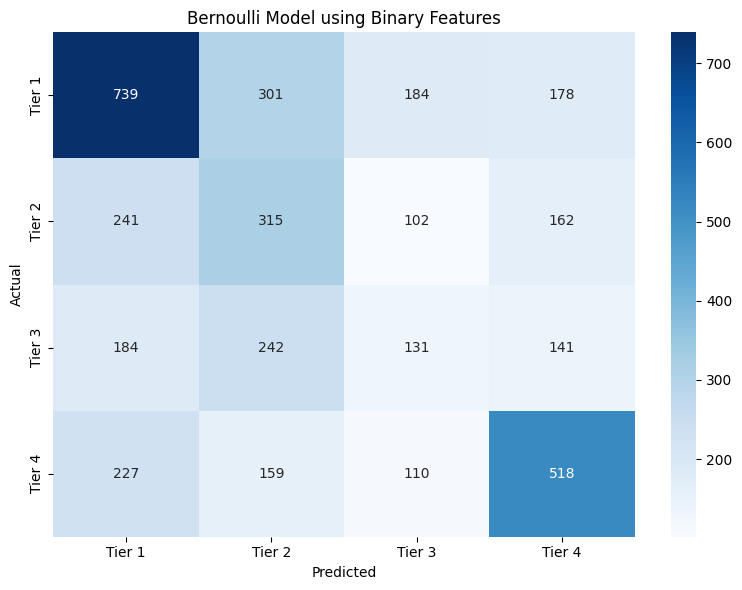

In [72]:
plot_heatmap(y_test_classification, bnb_pred, 'Bernoulli Model using Binary Features')

## ComplementNB

In [73]:
from sklearn.naive_bayes import ComplementNB

In [74]:
all_feature_cols = X_train_encoded.columns.tolist()
all_feature_cols.remove('Overall_Rating')

In [75]:
X_train_comp = X_train_encoded.copy()
X_test_comp = X_test_encoded.copy()

In [76]:
for col in all_feature_cols:
    if X_train_comp[col].dtype in ['float64', 'int64']:
        shift = X_train_comp[col].min()
        X_train_comp[col] = X_train_comp[col] - shift
        X_test_comp[col] = X_test_comp[col] - shift


In [77]:
cnb = ComplementNB()
cnb.fit(X_train_comp, y_classification)
cnb_pred = cnb.predict(X_test_comp)

In [78]:
evaluate_model(y_test_classification, cnb_pred)

Accuracy: 0.5673614641586172
Precision: 0.521929566851129
Recall: 0.5673614641586172
F1 score: 0.5053740374584427


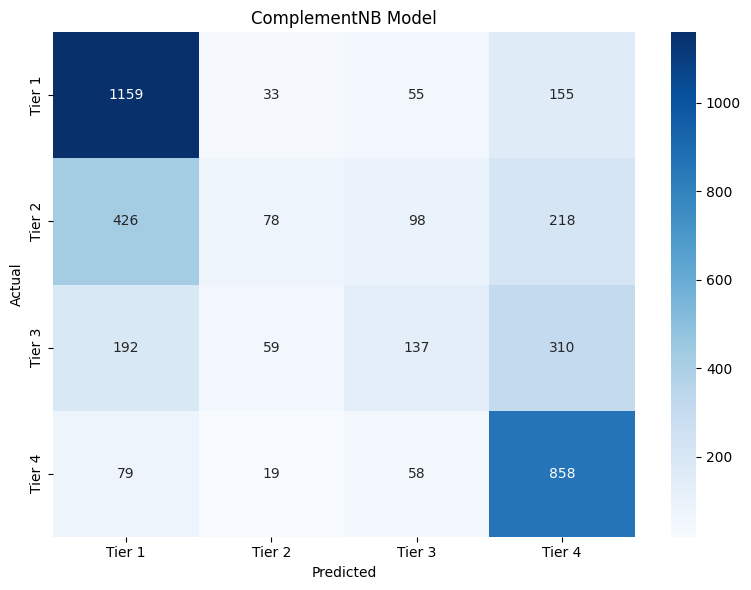

In [79]:
plot_heatmap(y_test_classification, cnb_pred, 'ComplementNB Model')

## Comparing the 3 models

In [95]:
models = {
    'GaussianNB': gnb_pred,
    'BernoulliNB': bnb_pred,
    'ComplementNB': cnb_pred
}

print("Model Comparison:")
for name, pred in models.items():
    acc = accuracy_score(y_test_classification, pred)
    prec = precision_score(y_test_classification, pred, average='weighted')
    rec = recall_score(y_test_classification, pred, average='weighted')
    f1 = f1_score(y_test_classification, pred, average='weighted')
    print(f"  {name} : Accuracy: {acc:.2%} | Precision: {prec:.2%} | Recall: {rec:.2%} | F1: {f1:.2%}")


Model Comparison:
  GaussianNB : Accuracy: 67.69% | Precision: 69.07% | Recall: 67.69% | F1: 68.30%
  BernoulliNB : Accuracy: 43.29% | Precision: 43.16% | Recall: 43.29% | F1: 43.07%
  ComplementNB : Accuracy: 56.74% | Precision: 52.19% | Recall: 56.74% | F1: 50.54%


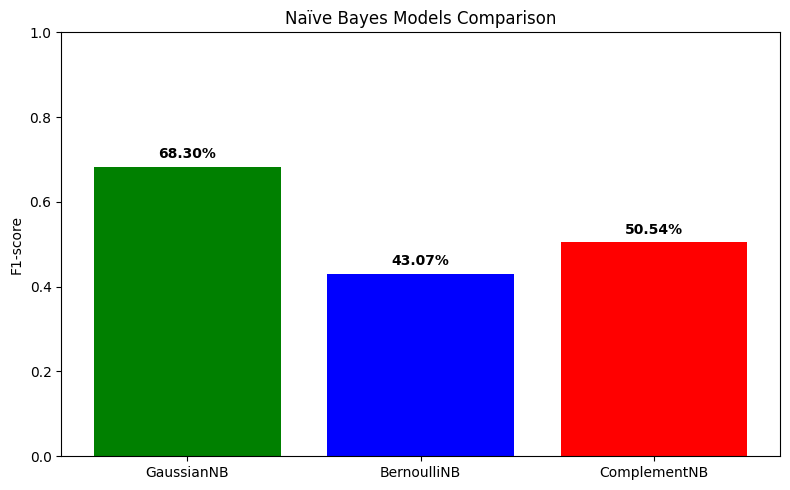

In [97]:
f1 = {name: f1_score(y_test_classification, pred, average='weighted') for name, pred in models.items()}
plt.figure(figsize=(8, 5))
plt.bar(f1.keys(), f1.values(), color=['green', 'blue', 'red'])
plt.ylabel('F1-score')
plt.title('Naïve Bayes Models Comparison')
plt.ylim(0, 1)
for i, (name, acc) in enumerate(f1.items()):
    plt.text(i, acc + 0.02, f'{acc:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### from the comparison above its obviously that Gaussian has the higher score.

### **Which Naïve Bayes variant is most appropriate?**

We tested each variant on the type of features it works best with: GaussianNB on numerical features, BernoulliNB on binary (one-hot encoded) features, and ComplementNB on non-negative features. Even though each model used the features most suited to it, GaussianNB still scored the highest (F1 = 68.30%). This means the numerical features carry the most useful information for classifying player performance tiers.


----------------------------------------

# Task 7: Model Evaluation with Cross-Validation


In [98]:
from sklearn.model_selection import cross_val_score, StratifiedKFold


## A. K-Fold Cross-Validation
our best regression model was Polynomial Degree 2

In [112]:
reg_model = LinearRegression()
reg_scores = cross_val_score(reg_model, X_train_squared, y_train_clean, cv=5, scoring='neg_root_mean_squared_error')

reg_rmse = -reg_scores  # to get positive RMSE
mean_rmse = reg_rmse.mean()
std_rmse = reg_rmse.std()

print("Regression 5-Fold CV Results:")
for i, score in enumerate(reg_rmse):
    print(f"  Fold {i+1}: RMSE = {score:.4f}")
print(f"  Mean RMSE : {mean_rmse:.4f}")
print(f"  Std       : {std_rmse:.4f}")


Regression 5-Fold CV Results:
  Fold 1: RMSE = 0.3421
  Fold 2: RMSE = 0.3066
  Fold 3: RMSE = 0.3016
  Fold 4: RMSE = 0.3162
  Fold 5: RMSE = 0.2936
  Mean RMSE : 0.3120
  Std       : 0.0167


### fold by fold bar chart

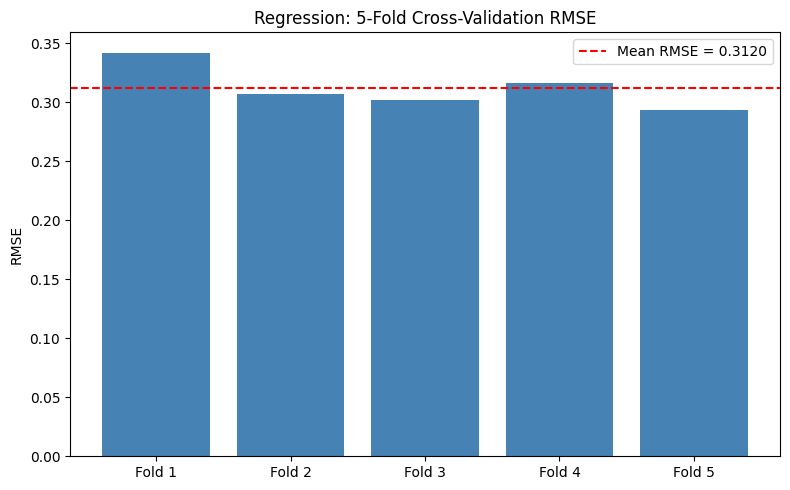

In [ ]:
folds = [f'Fold {i+1}' for i in range(5)]
plt.figure(figsize=(8, 5))
plt.bar(folds, reg_rmse, color='steelblue')
plt.axhline(y=mean_rmse, color='red', linestyle='--', label=f'Mean RMSE = {mean_rmse:.4f}')
plt.ylabel('RMSE')
plt.title('Regression: 5-Fold Cross-Validation RMSE')
plt.legend()
plt.tight_layout()
plt.show()


## B. Stratified K-Fold Cross-Validation
Apply StratifiedKFold (5 splits) to Logistic Regression and GaussianNB.

In [128]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

lr_model = LogisticRegression(max_iter=1000)

lr_scores = cross_val_score(lr_model, X_classification, y_classification, cv=skf, scoring='accuracy')

print("Logistic Regression - Stratified 5-Fold CV:")
for i, s in enumerate(lr_scores):
    print(f"  Fold {i+1}: Accuracy = {s:.4f}")
print(f"  Mean: {lr_scores.mean():.4f} | Std: {lr_scores.std():.4f}")



Logistic Regression - Stratified 5-Fold CV:
  Fold 1: Accuracy = 0.7277
  Fold 2: Accuracy = 0.7358
  Fold 3: Accuracy = 0.7398
  Fold 4: Accuracy = 0.7426
  Fold 5: Accuracy = 0.7374
  Mean: 0.7366 | Std: 0.0050


In [129]:
gnb_model = GaussianNB()
gnb_scores = cross_val_score(gnb_model, X_train_gnb, y_classification, cv=skf, scoring='accuracy')
print("\nGaussianNB - Stratified 5-Fold CV:")
for i, s in enumerate(gnb_scores):
    print(f"  Fold {i+1}: Accuracy = {s:.4f}")
print(f"  Mean: {gnb_scores.mean():.4f} | Std: {gnb_scores.std():.4f}")



GaussianNB - Stratified 5-Fold CV:
  Fold 1: Accuracy = 0.6602
  Fold 2: Accuracy = 0.6707
  Fold 3: Accuracy = 0.6703
  Fold 4: Accuracy = 0.6683
  Fold 5: Accuracy = 0.6667
  Mean: 0.6672 | Std: 0.0038


### LR vs GaussianNB fold-by-fold


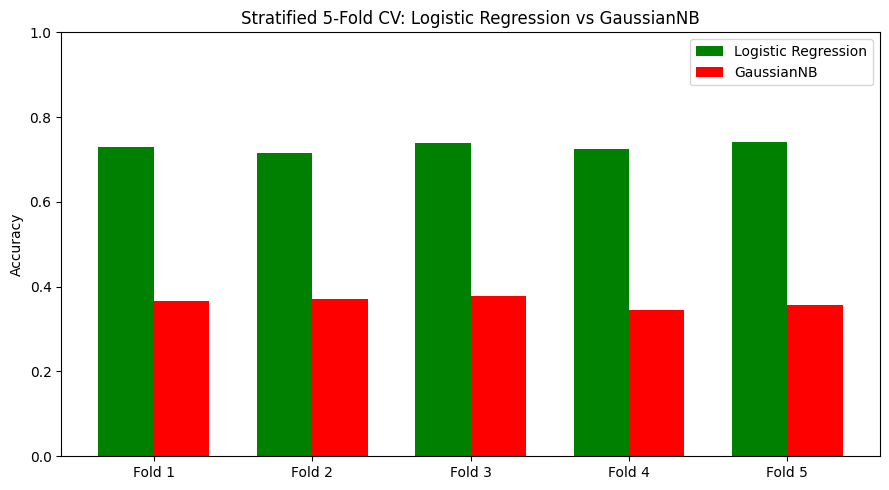

In [ ]:
x = np.arange(5)
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='green')
plt.bar(x + width/2, gnb_scores, width, label='GaussianNB', color='red')
plt.xticks(x, [f'Fold {i+1}' for i in range(5)])
plt.ylabel('Accuracy')
plt.title('Stratified 5-Fold CV: Logistic Regression vs GaussianNB')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

### **Conclusion**

##### Logistic Regression achieved a higher mean accuracy , making  better-performing model across folds.
##### however, even Gaussian got lower mean but lower sd making it stable and consistent across folds.


----
# Task 8: Analysis and Discussion

**8.1 Model Comparison**

*   **Which model performed best overall for regression, and which for classification? Justify briefly.**
     * For regression, Polynomial Regression (Degree 2) performed the best. Even though the 3rd-degree polynomial fit the training data better, the 2nd-degree generalized better on the test set. Ridge and Lasso didn't really improve things, as their lowest RMSE happened when alpha was practically 0. 
     * For classification, Logistic Regression (with L2 penalty) was the clear winner. It hit around 78% accuracy on the test set, whereas the best Naïve Bayes model (Gaussian) only got about 67.7%. Our cross-validation also backed this up, showing Logistic Regression having a higher mean accuracy across the folds.

*   **Is classification easier or harder than regression on this dataset? Why?**

    Classification was definitely easier.  

     * Regression: The target ("Value Per M$") was highly skewed with massive outliers, making predictions difficult.
     * Classification: The target was perfectly balanced into 4 tiers, making it much easier for the model to learn.



**8.2 Regularization Analysis**

*   **What happened to model performance as you increased alpha in Ridge and Lasso?**

    As alpha increased, the RMSE got worse (higher) for both models. If you look at the line plots we made, the error basically just goes up as the penalty gets stronger. That's why the optimal alpha ended up being close to 0, meaning the model actually preferred having almost no regularization at all.

*   **Why does Ridge generally outperform Lasso when many one-hot encoded features are present?**

    Since we one-hot encoded the 'Team' and 'Position' columns, we ended up with almost 1,000 features. Lasso uses an L1 penalty, which forces a lot of coefficients exactly to zero, basically dropping those features entirely. When you have a ton of one-hot encoded dummy variables, completely dropping them means you lose a lot of information about specific categories. Ridge uses an L2 penalty, which shrinks the weights to keep them small but doesn't force them to zero. This works way better for sparse, one-hot encoded data because it prevents overfitting without totally deleting the categories.


# Assignment 3: Unified Scouting System

## 1. Justify Your Modeling Choices

We have chosen the following four diverse algorithmic approaches for our Unified Scouting System, based on the dataset's characteristics (both linear and non-linear relationships, mixed categorical and numerical data, and multiple features):

1.  **XGBoost (Tree-based Ensemble):** XGBoost is highly suitable for our dataset as it natively handles non-linear relationships and interactions between player attributes. It is robust to outliers and generally provides state-of-the-art performance on tabular data like ours, without requiring extensive scaling.
2.  **Support Vector Machines / SVR (Kernel-based):** SVM with an RBF kernel maps our player features into a higher-dimensional space. This allows it to find complex boundaries for classification (Performance Tier) and capture non-linear patterns for regression (Player Value) that simple linear models might miss.
3.  **K-Nearest Neighbors (Instance-based):** KNN works by comparing a player to their most similar peers. Since player value and tier often correlate strongly with players of similar profiles (e.g., similar stats and age), this instance-based approach is a strong, intuitive baseline that captures local data structures well.
4.  **Multi-Layer Perceptron (Neural Network):** An MLP can learn highly complex, non-linear mappings from player stats to value and tier. With multiple hidden layers, it acts as a powerful universal approximator that can uncover deep feature interactions within our data.



In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from xgboost import XGBRegressor, XGBClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.ensemble import VotingRegressor, VotingClassifier
import warnings
warnings.filterwarnings('ignore')


## 2. Improve Model Performance Using Appropriate Techniques
### Systematic Optimization: Grid Search


In [ ]:
# Define regression models and parameter grids
reg_models = {
    'XGBoost': (XGBRegressor(random_state=42), {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1]
    }),
    'SVR': (SVR(), {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    }),
    'KNN': (KNeighborsRegressor(), {
        'n_neighbors': [3, 5, 9],
        'weights': ['uniform', 'distance']
    }),
    'MLP': (MLPRegressor(random_state=42, max_iter=500), {
        'hidden_layer_sizes': [(50,), (100,)],
        'alpha': [0.0001, 0.001]
    })
}

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_classification_encoded = le.fit_transform(y_classification)

clf_models = {
    'XGBoost': (XGBClassifier(random_state=42, eval_metric='mlogloss'), {
        'n_estimators': [50, 100],
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1]
    }),
    'SVC': (SVC(probability=True, random_state=42), {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    }),
    'KNN': (KNeighborsClassifier(), {
        'n_neighbors': [3, 5, 9],
        'weights': ['uniform', 'distance']
    }),
    'MLP': (MLPClassifier(random_state=42, max_iter=500), {
        'hidden_layer_sizes': [(50,), (100,)],
        'alpha': [0.0001, 0.001]
    })
}


In [ ]:
# Perform Grid Search for Regression
best_reg_models = {}
best_reg_params = {}

print("--- Regression Grid Search ---")
for name, (model, params) in reg_models.items():
    print(f"Optimizing {name} Regressor...")
    grid = GridSearchCV(model, params, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train_clean)
    best_reg_models[name] = grid.best_estimator_
    best_reg_params[name] = grid.best_params_
    print(f"Best parameters for {name}: {grid.best_params_}")
    print(f"Best CV R2 Score: {grid.best_score_:.4f}\n")



In [ ]:
# Perform Grid Search for Classification
best_clf_models = {}
best_clf_params = {}

print("--- Classification Grid Search ---")
for name, (model, params) in clf_models.items():
    print(f"Optimizing {name} Classifier...")
    grid = GridSearchCV(model, params, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_classification, y_classification_encoded)
    best_clf_models[name] = grid.best_estimator_
    best_clf_params[name] = grid.best_params_
    print(f"Best parameters for {name}: {grid.best_params_}")
    print(f"Best CV Accuracy Score: {grid.best_score_:.4f}\n")



### Error Diagnosis: Bias vs Variance (Learning Curves)


In [ ]:
def plot_learning_curve(estimator, title, X, y, cv, scoring='r2'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring=scoring
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel("Training examples")
    if scoring == 'r2':
        plt.ylabel("R2 Score")
    else:
        plt.ylabel("Accuracy")
        
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

# Plot learning curve for the best XGBoost Regressor as a representative example
plot_learning_curve(best_reg_models['XGBoost'], "Learning Curve (XGBoost Regressor)", X_train_scaled, y_train_clean, cv=3, scoring='r2')
plot_learning_curve(best_clf_models['XGBoost'], "Learning Curve (XGBoost Classifier)", X_classification, y_classification_encoded, cv=3, scoring='accuracy')

print("Diagnosis: If the training score is high but CV score is low, it implies high variance (overfitting).")
print("If both scores are low, it implies high bias (underfitting).")
print("The curves converging closely to a high score indicates a well-balanced model.")



### Architectural Synergy (Ensembling): Committee of Models


In [ ]:
# Build Voting Regressor using the best models
reg_estimators = [(name, model) for name, model in best_reg_models.items()]
ensemble_reg = VotingRegressor(estimators=reg_estimators)
ensemble_reg.fit(X_train_scaled, y_train_clean)

ensemble_reg_pred = ensemble_reg.predict(X_test_scaled)
print(f"Ensemble Regressor R2 Score on Test Set: {r2_score(y_test, ensemble_reg_pred):.4f}")

# Build Voting Classifier using the best models (Soft Voting)
clf_estimators = [(name, model) for name, model in best_clf_models.items()]
ensemble_clf = VotingClassifier(estimators=clf_estimators, voting='soft')
ensemble_clf.fit(X_classification, y_classification_encoded)

ensemble_clf_pred = ensemble_clf.predict(X_test_classification)
y_test_classification_encoded = le.transform(y_test_classification)
print(f"Ensemble Classifier Accuracy on Test Set: {accuracy_score(y_test_classification_encoded, ensemble_clf_pred):.4f}")



## 3. Build a System That Predicts an Outcome
### Unified Inference Pipeline


In [ ]:
class UnifiedScoutingSystem:
    def __init__(self, ensemble_reg, ensemble_clf, scaler, cat_cols, original_columns, label_encoder):
        self.regressor = ensemble_reg
        self.classifier = ensemble_clf
        self.scaler = scaler
        self.cat_cols = cat_cols
        self.original_columns = original_columns
        self.label_encoder = label_encoder
        
    def predict(self, raw_player_data):
        # 1. One-Hot Encoding
        encoded_data = pd.get_dummies(raw_player_data, columns=self.cat_cols, drop_first=True)
        
        # Ensure all columns match the training data
        for col in self.original_columns:
            if col not in encoded_data.columns:
                encoded_data[col] = 0
                
        # Reorder to match training
        encoded_data = encoded_data[self.original_columns]
        
        # 2. Scaling
        scaled_data = pd.DataFrame(self.scaler.transform(encoded_data), columns=self.original_columns)
        
        # 3. Predict Value
        predicted_value = self.regressor.predict(scaled_data)
        
        # 4. Predict Performance Tier
        if 'Overall_Rating' in scaled_data.columns:
            clf_features = scaled_data.drop(columns=['Overall_Rating'])
        else:
            clf_features = scaled_data
            
        predicted_tier_encoded = self.classifier.predict(clf_features)
        predicted_tier = self.label_encoder.inverse_transform(predicted_tier_encoded)
        
        return {
            'Predicted_Value_Per_M$': predicted_value,
            'Predicted_Performance_Tier': predicted_tier
        }

unified_system = UnifiedScoutingSystem(
    ensemble_reg=ensemble_reg,
    ensemble_clf=ensemble_clf,
    scaler=scaler,
    cat_cols=cat_cols,
    original_columns=X_train_encoded.columns,
    label_encoder=le
)

# Test the unified system with the first row of X_test
sample_player = X_test.iloc[[0]].copy()
print("Raw Player Profile:")
display(sample_player)

predictions = unified_system.predict(sample_player)
print("\nUnified Inference Predictions:")
for key, val in predictions.items():
    print(f"{key}: {val[0]}")



### Stability Assessment and System Comparison


In [ ]:
cv_folds = 5
print(f"--- Stability Assessment ({cv_folds}-Fold CV) ---")

cv_reg_scores = cross_val_score(ensemble_reg, X_train_scaled, y_train_clean, cv=cv_folds, scoring='r2', n_jobs=-1)
reg_cv_mean = np.mean(cv_reg_scores)
reg_cv_std = np.std(cv_reg_scores)
print(f"Ensemble Regression R2 CV Mean: {reg_cv_mean:.4f}")
print(f"Ensemble Regression R2 CV Std: {reg_cv_std:.4f}\n")

skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
cv_clf_scores = cross_val_score(ensemble_clf, X_classification, y_classification_encoded, cv=skf, scoring='accuracy', n_jobs=-1)
clf_cv_mean = np.mean(cv_clf_scores)
clf_cv_std = np.std(cv_clf_scores)
print(f"Ensemble Classification Accuracy CV Mean: {clf_cv_mean:.4f}")
print(f"Ensemble Classification Accuracy CV Std: {clf_cv_std:.4f}\n")

print("--- System Comparison ---")
print("Baseline Regression (Linear Regression CV from Assign 2):")
baseline_reg = LinearRegression()
baseline_reg.fit(X_train_scaled, y_train_clean)
base_reg_r2 = r2_score(y_test, baseline_reg.predict(X_test_scaled))
print(f"Baseline Linear Regression Test R2: {base_reg_r2:.4f}")
print(f"Unified System Regression Test R2: {r2_score(y_test, ensemble_reg_pred):.4f}")

print("\nBaseline Classification (Logistic Regression from Assign 2):")
baseline_clf = LogisticRegression(random_state=42)
baseline_clf.fit(X_classification, y_classification_encoded)
base_clf_acc = accuracy_score(y_test_classification_encoded, baseline_clf.predict(X_test_classification))
print(f"Baseline Logistic Regression Test Accuracy: {base_clf_acc:.4f}")
print(f"Unified System Classification Test Accuracy: {accuracy_score(y_test_classification_encoded, ensemble_clf_pred):.4f}")



## Deliverables: Export results.json


In [ ]:
group_members = [
    {"name": "Waddah Ali Mustafa", "id": "2401243012"},
    {"name": "Karam Mohammed Karam", "id": "2401248066"},
    {"name": "Mohammed Ahmed Mohammed", "id": "2401243613"},
    {"name": "Eman Hashim Mohammed", "id": "2401245650"},
    {"name": "Eltayeb Mohammed Eltayeb", "id": "2401246443"}
]

def serialize_params(params_dict):
    out = {}
    for k, v in params_dict.items():
        if isinstance(v, (np.int64, np.int32)):
            out[k] = int(v)
        elif isinstance(v, (np.float64, np.float32)):
            out[k] = float(v)
        elif isinstance(v, tuple):
            out[k] = list(v)
        else:
            out[k] = v
    return out

best_hyperparameters = {
    "Regression": {name: serialize_params(params) for name, params in best_reg_params.items()},
    "Classification": {name: serialize_params(params) for name, params in best_clf_params.items()}
}

cv_stability = {
    "Regression_R2": {
        "mean": float(reg_cv_mean),
        "std": float(reg_cv_std)
    },
    "Classification_Accuracy": {
        "mean": float(clf_cv_mean),
        "std": float(clf_cv_std)
    }
}

results = {
    "group_members": group_members,
    "best_hyperparameters": best_hyperparameters,
    "cv_stability": cv_stability
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

print("results.json successfully exported!")

